In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from utils import *
import sys
from astropy.io import fits
import cloud_model_torch as cmt 
import matplotlib

In [2]:
# Default matplotlib settings
matplotlib.rcParams['image.interpolation'] = 'nearest'

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# Add after imports
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# ====================================================================
def optimization(optimizer,niterations,parameters,model, xl, img):
    """
    This function performs the optimization of the parameters of the model.
    """
    # Move data to GPU if not already there:
    if not isinstance(img, torch.Tensor):
        img = torch.from_numpy(np.array(img.astype(np.float32)))
    if img.device != parameters.device:
        img = img.to(device)
    
    from tqdm import trange
    t = trange(niterations, leave=True)
    for loop in t:
        optimizer.zero_grad()        #reset gradients
        img_syn = cloud_model(xl, parameters)
        img_syn = img_syn.reshape(img.shape[0], img.shape[1], -1)
        chi2loss = torch.mean(torch.sum((img - img_syn)**2.0))
        
        reguloss = chi2loss*0.0
        #reguloss += 1e1*regu2(parameters, 0,img)
        #reguloss += 1e1*regu2(parameters, 1,img) 
        #reguloss += 1e-1*regu2(parameters, 2,img)
        #reguloss += 5e-2*regu2(parameters, 3,img)
        #reguloss += 5e-2*regu2(parameters, 4,img)
        #reguloss += 1e1*regu2(parameters, 5,img)
        #reguloss += 1e2*regu2(parameters, 6,img)
        #reguloss += 2e-2*regu2(parameters, 8,img)

        loss = chi2loss + reguloss

        loss.backward()              #calculate gradients

        optimizer.step()             #step fordward

        t.set_postfix({'loss': loss.item(), 'chi2loss': chi2loss.item(), 'reguloss': reguloss.item()})

        
        if (chi2loss.item() != chi2loss.item()):  #check for NaN
            print("NaN detected. Stopping optimization.")
            print(parameters)
            break

    parameters = parameters.reshape(img.shape[0],img.shape[1],-1)
    parameters = parameters.detach().cpu().numpy()
    img_syn = img_syn.detach().cpu().numpy()
    return parameters, img_syn


In [62]:
# ========================================================================================================
def cloud_model(x, params):
    #return cmt.model_synth(x, params)
    return cmt.model_synth_2clouds(x, params)


In [63]:
# ================================================================================================================
# Readind the data:

# data_filename = "/mn/stornext/d20/RoCS/carlosjd/colabs/ivan/MIHI/cloudinv_mihi/data/mihi_data.fits"
# data_filename = "/home/milic/data/scratch/mihi_data.fits"
# data_filename = "/home/milic/data/img_fit.210800..211599.00.00.lr0250.cube.fits"
data_filename = "/home/milic/data/scratch/img_fit.210800..211599.00.00.lr0250.cube.fits"


tofit = fits.open(data_filename)[0].data[15:-15, 15:-15,0,100:500]
Iqs = np.mean(tofit[:,:,-20])
print("info::normalizing the input data to the value: ", Iqs)
tofit /= Iqs
tofit = tofit.astype(float)
print("info::the input observations have the shape:", tofit.shape)
xl = fits.open(data_filename)[1].data[100:500]
ll0 = np.asarray([np.mean(xl)])
xl = [xl,ll0]



# Transform data into pytorch object:
tofit_pt = torch.from_numpy(np.array(tofit.astype(np.float32))).to(device)


info::normalizing the input data to the value:  6.7399073
info::the input observations have the shape: (116, 130, 400)


In [75]:
tofit = tofit[0,82,:].reshape(1,1,-1)
tofit_pt = tofit_pt[0,82,:].reshape(1,1,-1)

IndexError: index 82 is out of bounds for axis 1 with size 1

In [81]:
# ================================================================================================================
# Defining the parameters of the model in the FOV:
pars = torch.ones(tofit.shape[0]*tofit.shape[1], 16, device=device) # (NX x NY) x NP cube

# Initialize the starting values:
pars[:,0] = 0.4 # S0
pars[:,1] = 0.85 # S1
pars[:,2] = 3.0 # eta in units if 1000s
pars[:,3] = 12.0 # los velocity
pars[:,4] = 10.0 # doppler width 
pars[:,5] = -2.0 # log a

# Cloud: 
pars[:,6] = 0.4 # S
pars[:,7] = 4.5 # tau
pars[:,8] = -2.0 # los velocity
pars[:,9] = 6.0 # Doppler width
pars[:,10] = -4.0 # log a

# Cloud: 
pars[:,11] = 0.1 # S
pars[:,12] = 1.0 # tau
pars[:,13] = 10.0 # los velocity
pars[:,14] = 5.0 # Doppler width
pars[:,15] = -5.0 # log a

pars.requires_grad = True


In [82]:
# Parameters:
print("info:: parameters:", torch.mean(pars, axis=(0)))

info:: parameters: tensor([ 0.4000,  0.8500,  3.0000, 12.0000, 10.0000, -2.0000,  0.4000,  4.5000,
        -2.0000,  6.0000, -4.0000,  0.1000,  1.0000, 10.0000,  5.0000, -5.0000],
       device='cuda:0', grad_fn=<MeanBackward1>)


In [83]:
torch.cuda.empty_cache()

In [84]:
# ====================================================================
# Send all the info to the optimization module inside the utils.py file:
optimizer = torch.optim.Adam([pars], lr=5e-1)
niter = 50
mymodel = cloud_model # Model from the above
parameters, fit_spectra = optimization(optimizer=optimizer,niterations=niter,
                                        parameters=pars,model=mymodel,xl=xl,img=tofit)

chisq = np.sum((tofit - fit_spectra)**2.0, axis=2) / 400.0
print(np.mean(chisq[0,0]))



  0%|          | 0/50 [00:00<?, ?it/s, loss=32.8, chi2loss=32.8, reguloss=0]

 16%|█▌        | 8/50 [00:00<00:00, 74.07it/s, loss=12.6, chi2loss=12.6, reguloss=0]

tensor([[-0.1000,  0.3500,  3.5000, 11.5000, 10.5000, -1.5000, -0.1000,  5.0000,
         -2.5000,  6.5000, -3.5000,  0.6000,  0.5000,  9.5000,  5.5000, -4.5002]],
       device='cuda:0', requires_grad=True)
tensor([[-0.5957,  0.2229,  3.6906, 11.1118, 10.6733, -1.3324, -0.5870,  5.3026,
         -2.8058,  6.8083, -3.3099,  1.1004,  0.8200,  9.5370,  5.9613, -4.0536]],
       device='cuda:0', requires_grad=True)
tensor([[-0.8964,  0.1089,  3.8461, 10.7829, 10.8171, -1.1932, -0.4386,  5.6866,
         -3.1030,  7.1700, -3.0281,  0.8071,  0.5263,  9.8001,  5.7200, -3.5873]],
       device='cuda:0', requires_grad=True)
tensor([[-0.9053, -0.0408,  3.9885, 10.5019, 10.9522, -1.0605, -0.1671,  5.9889,
         -3.4268,  7.4735, -2.7324,  0.4497,  0.2663, 10.1613,  5.5027, -3.2772]],
       device='cuda:0', requires_grad=True)
tensor([[-0.7697, -0.1276,  4.1127, 10.2614, 11.0709, -0.9433,  0.0927,  6.3619,
         -3.8108,  7.8466, -2.3984,  0.0990,  0.2167, 10.5701,  5.3808, -2.8991]],
    

 48%|████▊     | 24/50 [00:00<00:00, 69.12it/s, loss=1.4, chi2loss=1.4, reguloss=0]    

tensor([[-0.9055, -0.7513,  4.6571,  8.6666, 11.5529, -0.5085,  0.1250,  9.5794,
         -7.1324, 11.1390,  0.4153, -0.8454, -0.3164, 13.4465,  4.7406,  0.2519]],
       device='cuda:0', requires_grad=True)
tensor([[-0.9468, -0.7859,  4.6799,  8.5667, 11.5722, -0.4915,  0.0739,  9.9641,
         -7.5237, 11.4552,  0.6805, -0.8173, -0.4499, 13.5085,  4.6843,  0.7064]],
       device='cuda:0', requires_grad=True)
tensor([[-0.9886, -0.8182,  4.6990,  8.4722, 11.5878, -0.4784, -0.0167, 10.3535,
         -7.9340, 11.7049,  0.6808, -0.7865, -0.5560, 13.5745,  4.6266,  1.1581]],
       device='cuda:0', requires_grad=True)
tensor([[-1.0351, -0.8485,  4.7144,  8.3829, 11.5995, -0.4695, -0.0980, 10.6572,
         -8.3638, 11.8769,  0.5612, -0.7612, -0.6495, 13.6367,  4.5733,  1.6201]],
       device='cuda:0', requires_grad=True)
tensor([[-1.0821, -0.8765,  4.7276,  8.2986, 11.6091, -0.4626, -0.1404, 10.9443,
         -8.8144, 12.0040,  0.3642, -0.7384, -0.7322, 13.6935,  4.5244,  2.0940]],
    

 78%|███████▊  | 39/50 [00:00<00:00, 70.39it/s, loss=nan, chi2loss=nan, reguloss=nan]  


tensor([[ -1.2444,  -1.0353,   4.9103,   7.5796,  11.7847,  -0.2760,  -0.1432,
          14.2890, -15.1596,  13.9546,   0.2913,  -0.5639,  -1.3237,  14.1005,
           4.1739,   5.5107]], device='cuda:0', requires_grad=True)
tensor([[ -1.2482,  -1.0401,   4.9199,   7.5485,  11.7946,  -0.2646,  -0.2179,
          14.3788, -15.5539,  14.0296,   0.3243,  -0.5573,  -1.3460,  14.1159,
           4.1607,   5.6379]], device='cuda:0', requires_grad=True)
tensor([[ -1.2530,  -1.0445,   4.9285,   7.5197,  11.8034,  -0.2544,  -0.2640,
          14.4597, -15.9259,  14.0904,   0.3336,  -0.5513,  -1.3664,  14.1299,
           4.1486,   5.7538]], device='cuda:0', requires_grad=True)
tensor([[ -1.2561,  -1.0484,   4.9365,   7.4932,  11.8117,  -0.2449,  -0.2260,
          14.5701, -16.2713,  14.1567,   0.3222,  -0.5458,  -1.3849,  14.1426,
           4.1377,   5.8593]], device='cuda:0', requires_grad=True)
tensor([[ -1.2602,  -1.0520,   4.9437,   7.4687,  11.8190,  -0.2364,  -0.1657,
          14.6716

In [59]:
# Average the parameters for only print:
print("info::average parameters:", np.mean(parameters, axis=(0,1)))

info::average parameters: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]


In [60]:
parameters.shape

(1, 1, 16)

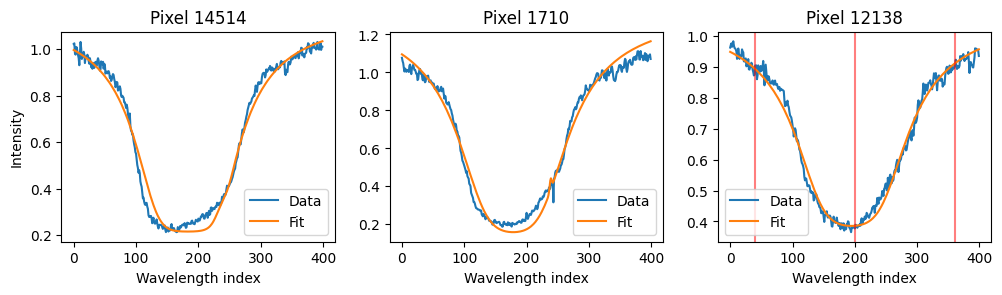

In [13]:
# Extract and compare 3 random pixels from the fit and the data:
np.random.seed(91)
idxs = np.random.randint(0, tofit.shape[0]*tofit.shape[1], size=3)
plt.figure(figsize=[12,6])
for j, idx in enumerate(idxs):
    plt.subplot(2, 3, j+1)
    plt.plot(tofit.reshape(-1, tofit_pt.shape[2])[idx], label='Data')
    plt.plot(fit_spectra.reshape(-1, fit_spectra.shape[2])[idx], label='Fit')
    plt.title(f"Pixel {idx}")
    plt.xlabel('Wavelength index')
    plt.legend()
    if j == 0:
        plt.ylabel('Intensity')
        
# Vertical lines at:
idxs_lambda = [int(0.1*tofit.shape[2]), int(0.5*tofit.shape[2]), int(0.9*tofit.shape[2])]
for idx_lambda in idxs_lambda:
    plt.axvline(x=idx_lambda, color='r', linestyle='-', label=f'Wavelength {idx_lambda}', alpha=0.5)

plt.savefig('mihi_random_spectra_coupled.png', bbox_inches='tight', dpi=300)

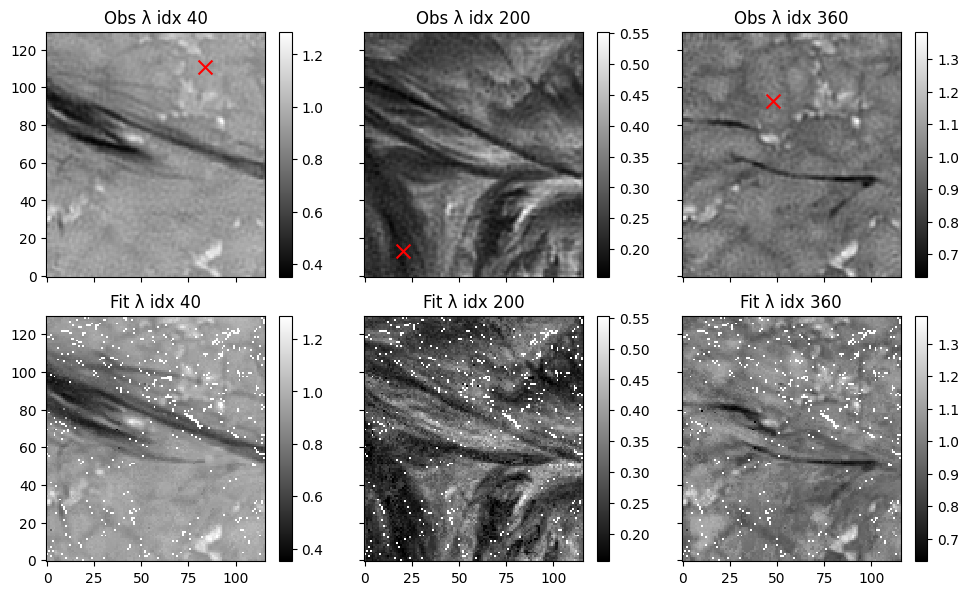

In [40]:
fig, axes = plt.subplots(2, 3, figsize=[10, 6], sharex=True, sharey=True)
for j, idx in enumerate(idxs_lambda):
    ax_obs = axes[0, j]
    im_obs = ax_obs.imshow(tofit[:, :, idx].T, origin='lower', cmap='gray')
    ax_obs.set_title(f"Obs λ idx {idx}")
    fig.colorbar(im_obs, ax=ax_obs)
    ax_obs.scatter(idxs[j] % tofit.shape[1], idxs[j] // tofit.shape[1], color='red', marker='x', s=100)

    ax_fit = axes[1, j]
    im_fit = ax_fit.imshow(fit_spectra[:, :, idx].T, origin='lower', cmap='gray',
                          vmin=tofit_pt[:, :, idx].min(), vmax=tofit_pt[:, :, idx].max())
    ax_fit.set_title(f"Fit λ idx {idx}")
    fig.colorbar(im_fit, ax=ax_fit)
plt.tight_layout()
plt.savefig('mihi_fit_images_coupled.png', bbox_inches='tight', dpi=300)


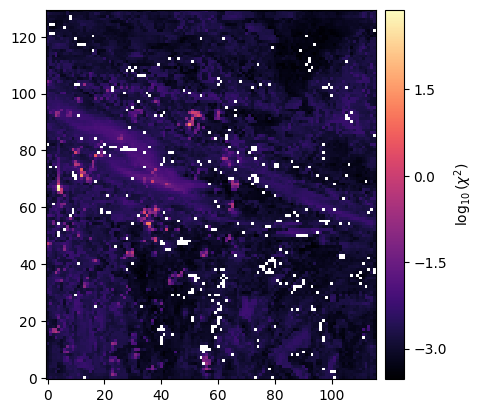

In [14]:
im = plt.imshow(np.log10(chisq).T, origin='lower', cmap='magma')
add_colorbar(im, label=r'$\log_{10}(\chi^2)$')

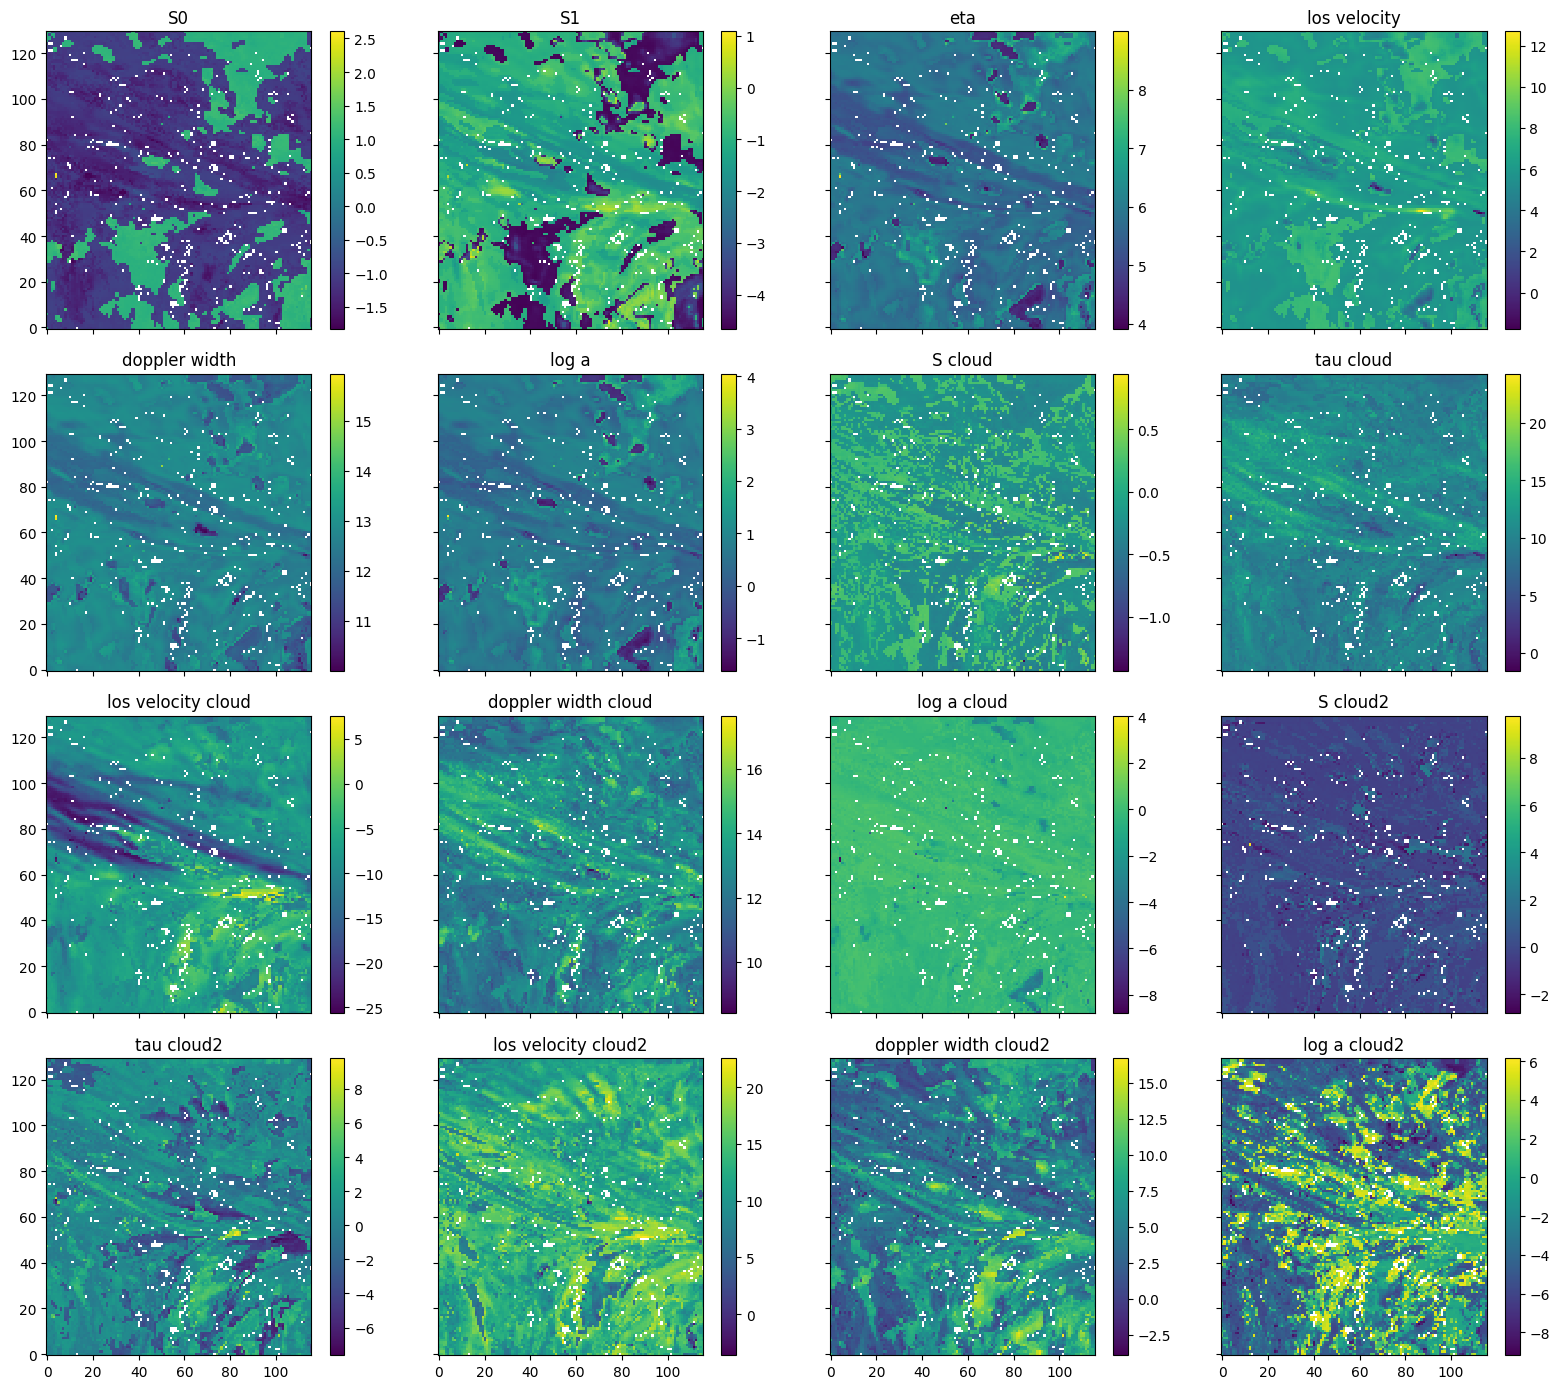

In [15]:
labels = ['S0', 'S1', 'eta', 'los velocity', 'doppler width', 'log a',
          'S cloud', 'tau cloud', 'los velocity cloud', 'doppler width cloud',
          'log a cloud', 'S cloud2', 'tau cloud2', 'los velocity cloud2',
          'doppler width cloud2', 'log a cloud2']
fig, axes = plt.subplots(4, 4, figsize=[16, 14], sharex=True, sharey=True)
ax = axes.flatten()
for i in range(16):
    im = ax[i].imshow(parameters[:, :, i].T, origin='lower')
    ax[i].set_title(labels[i])
    fig.colorbar(im, ax=ax[i])
plt.tight_layout()

plt.savefig('mihi_parameters_coupled.png', bbox_inches='tight', dpi=300)


In [16]:
# find one Nan
bad = np.where(np.isnan(chisq))

In [22]:
bad = np.asarray(bad)

In [23]:
bad.shape

(2, 393)

In [24]:
bad[:,0]

array([ 0, 82])

In [28]:
print (parameters[0,82,:])

[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
